# NSE NIFTY Options Pricing & Portfolio Risk Analytics

**Finance Lab Project — Real NSE Data | Dynamic Derivative Pricing | Greeks | Sensitivity | Portfolio Hedging**

This notebook prices and analyses NIFTY options using real NSE data, demonstrates linked spot/volatility inputs, calculates option Greeks and payoff profiles, tests volatility sensitivity, and extends the analysis to a hypothetical ₹10 crore equity portfolio hedged with NIFTY futures.


In [4]:
# CELL 1 — LIBRARIES & GLOBAL SETTINGS

import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq
from google.colab import files

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("=" * 65)
print("NSE NIFTY OPTIONS PRICING & RISK ANALYTICS")
print("=" * 65)
print("Engine initialized successfully")


NSE NIFTY OPTIONS PRICING & RISK ANALYTICS
Engine initialized successfully


In [5]:
# CELL 2 — UPLOAD REAL NSE DATA

print("Upload the NSE OPTION CHAIN CSV")
option_upload = files.upload()
option_filename = list(option_upload.keys())[0]

print("\nUpload the NIFTY HISTORICAL CSV")
history_upload = files.upload()
history_filename = list(history_upload.keys())[0]

print("\nFILES LOADED")
print("Option Chain :", option_filename)
print("NIFTY History:", history_filename)


Upload the NSE OPTION CHAIN CSV


Saving option-chain-ED-NIFTY-22-Sep-2026.csv to option-chain-ED-NIFTY-22-Sep-2026 (2).csv

Upload the NIFTY HISTORICAL CSV


Saving NIFTY 50-20-09-2025-to-20-09-2026.csv to NIFTY 50-20-09-2025-to-20-09-2026.csv

FILES LOADED
Option Chain : option-chain-ED-NIFTY-22-Sep-2026 (2).csv
NIFTY History: NIFTY 50-20-09-2025-to-20-09-2026.csv


In [6]:
# CELL 3 — CLEAN NIFTY HISTORICAL DATA

nifty_history = pd.read_csv(io.BytesIO(history_upload[history_filename]))
nifty_history.columns = nifty_history.columns.str.strip()

nifty_history["Date"] = pd.to_datetime(
    nifty_history["Date"],
    format="%d-%b-%Y",
    errors="coerce"
)

nifty_history["Close"] = pd.to_numeric(
    nifty_history["Close"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

nifty_history = (
    nifty_history
    .dropna(subset=["Date", "Close"])
    .sort_values("Date")
    .reset_index(drop=True)
)

observation_date = nifty_history["Date"].iloc[-1]
S = float(nifty_history["Close"].iloc[-1])

print("NIFTY HISTORY LOADED")
print("-" * 45)
print("Observations :", len(nifty_history))
print("First Date   :", nifty_history["Date"].iloc[0].date())
print("Last Date    :", observation_date.date())
print(f"NIFTY Spot   : {S:,.2f}")

display(nifty_history.tail())


NIFTY HISTORY LOADED
---------------------------------------------
Observations : 246
First Date   : 2025-09-22
Last Date    : 2026-09-18
NIFTY Spot   : 23,346.40


,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
241,2026-09-11,"23,270.3000","23,448.1000","23,231.4000","23,398.1000",293025966,"20,905.9700"
242,2026-09-15,"23,576.1500","23,592.8500","23,118.6000","23,118.6000",338835704,"26,523.1700"
243,2026-09-16,"23,201.6000","23,284.7500","23,116.1000","23,217.6000",261617344,"20,182.0800"
244,2026-09-17,"23,195.2500","23,363.5500","23,193.6500","23,270.6000",259700999,"18,775.3000"
245,2026-09-18,"23,334.7000","23,389.1500","23,286.6000","23,346.4000",375346024,"31,510.2800"


In [7]:
# CELL 4 — CLEAN NSE OPTION CHAIN

option_chain_raw = pd.read_csv(
    io.BytesIO(option_upload[option_filename]),
    skiprows=1
)

option_chain_raw.columns = option_chain_raw.columns.str.strip()
option_chain_raw = option_chain_raw.dropna(axis=1, how="all")

chain = pd.DataFrame({
    "Strike": option_chain_raw["STRIKE"],
    "Call_OI": option_chain_raw["OI"],
    "Call_Volume": option_chain_raw["VOLUME"],
    "Call_IV": option_chain_raw["IV"],
    "Call_LTP": option_chain_raw["LTP"],
    "Call_Bid": option_chain_raw["BID"],
    "Call_Ask": option_chain_raw["ASK"],
    "Put_Bid": option_chain_raw["BID.1"],
    "Put_Ask": option_chain_raw["ASK.1"],
    "Put_LTP": option_chain_raw["LTP.1"],
    "Put_IV": option_chain_raw["IV.1"],
    "Put_Volume": option_chain_raw["VOLUME.1"],
    "Put_OI": option_chain_raw["OI.1"]
})

for col in chain.columns:
    chain[col] = pd.to_numeric(
        chain[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

chain = (
    chain.dropna(subset=["Strike"])
    .sort_values("Strike")
    .reset_index(drop=True)
)

print(f"Option chain loaded: {len(chain)} strikes")
display(chain.head())


Option chain loaded: 96 strikes


,Strike,Call_OI,Call_Volume,Call_IV,Call_LTP,Call_Bid,Call_Ask,Put_Bid,Put_Ask,Put_LTP,Put_IV,Put_Volume,Put_OI
0,"21,350.0000",NaN,NaN,NaN,NaN,"1,900.7500","2,080.4500",1.0500,1.1000,1.1000,33.1300,"188,886.0000","97,418.0000"
1,"21,400.0000",NaN,NaN,NaN,NaN,"1,797.7000","2,030.5500",0.9000,1.2500,0.9000,31.6800,"180,385.0000","56,985.0000"
2,"21,450.0000",NaN,NaN,NaN,NaN,"1,777.2000","1,980.4500",0.9000,1.3000,1.0000,31.2700,"35,989.0000","9,629.0000"
3,"21,500.0000",NaN,NaN,NaN,NaN,"1,741.6000","1,930.7500",1.1500,1.2000,1.2000,31.1200,"205,553.0000","71,069.0000"
4,"21,550.0000",NaN,NaN,NaN,NaN,"1,691.8500","1,880.5000",1.2500,1.3500,1.1500,30.2000,"34,317.0000","3,794.0000"


In [8]:
# CELL 5 — MARKET ASSUMPTIONS, EXPIRY & AUTOMATIC ATM SELECTION

# Central assumptions for this observation date.
# Update ONLY here if a different dated dataset is used.
RISK_FREE_RATE = 0.052801
DIVIDEND_YIELD = 0.0120

r = RISK_FREE_RATE
q = DIVIDEND_YIELD

# Extract expiry from filename such as:
# option-chain-ED-NIFTY-22-Sep-2026.csv
expiry_match = re.search(
    r"(\d{1,2}-[A-Za-z]{3}-\d{4})",
    option_filename
)

if expiry_match:
    expiry_date = pd.to_datetime(expiry_match.group(1), format="%d-%b-%Y")
else:
    raise ValueError(
        "Expiry date could not be read from the option-chain filename."
    )

days_to_expiry = (expiry_date - observation_date).days

if days_to_expiry <= 0:
    raise ValueError("Expiry must be after the observation date.")

T = days_to_expiry / 365.0

chain["Distance_from_Spot"] = abs(chain["Strike"] - S)
atm_index = chain["Distance_from_Spot"].idxmin()
atm = chain.loc[atm_index]

K = float(atm["Strike"])
call_market = float(atm["Call_LTP"])
put_market = float(atm["Put_LTP"])
nse_call_iv = float(atm["Call_IV"]) / 100
nse_put_iv = float(atm["Put_IV"]) / 100

print("=" * 55)
print("REAL NSE ATM CONTRACT")
print("=" * 55)
print(f"Observation Date : {observation_date.date()}")
print(f"Expiry           : {expiry_date.date()}")
print(f"Days to Expiry   : {days_to_expiry}")
print(f"NIFTY Spot       : {S:,.2f}")
print(f"ATM Strike       : {K:,.0f}")
print(f"Call LTP         : ₹{call_market:.2f}")
print(f"Put LTP          : ₹{put_market:.2f}")
print(f"NSE Call IV      : {nse_call_iv:.2%}")
print(f"NSE Put IV       : {nse_put_iv:.2%}")
print(f"Risk-free Rate   : {r:.4%}")
print(f"Dividend Yield   : {q:.2%}")

start = max(atm_index - 5, 0)
end = min(atm_index + 6, len(chain))
display(chain.loc[start:end-1, [
    "Strike", "Call_LTP", "Call_IV", "Call_OI",
    "Put_LTP", "Put_IV", "Put_OI"
]])


REAL NSE ATM CONTRACT
Observation Date : 2026-09-18
Expiry           : 2026-09-22
Days to Expiry   : 4
NIFTY Spot       : 23,346.40
ATM Strike       : 23,350
Call LTP         : ₹88.05
Put LTP          : ₹84.65
NSE Call IV      : 7.86%
NSE Put IV       : 9.77%
Risk-free Rate   : 5.2801%
Dividend Yield   : 1.20%


,Strike,Call_LTP,Call_IV,Call_OI,Put_LTP,Put_IV,Put_OI
35,"23,100.0000",274.5000,6.5200,"9,145.0000",21.2000,10.9400,"98,921.0000"
36,"23,150.0000",231.0500,7.3600,"5,379.0000",27.9000,10.6100,"60,052.0000"
37,"23,200.0000",188.9000,7.5100,"41,008.0000",35.0000,10.0700,"147,721.0000"
38,"23,250.0000",151.7000,7.7800,"27,873.0000",49.0500,10.1000,"99,857.0000"
39,"23,300.0000",117.5000,7.8300,"114,149.0000",64.4500,9.8800,"195,178.0000"
40,"23,350.0000",88.0500,7.8600,"76,240.0000",84.6500,9.7700,"79,124.0000"
41,"23,400.0000",64.0000,7.9100,"134,896.0000",110.3000,9.8100,"73,651.0000"
42,"23,450.0000",44.6500,7.9300,"59,383.0000",140.3000,9.8700,"10,717.0000"
43,"23,500.0000",30.0500,7.9600,"141,941.0000",176.0000,10.1500,"37,004.0000"
44,"23,550.0000",19.3500,7.9800,"56,236.0000",213.6500,10.3000,"4,039.0000"


In [9]:
# CELL 6 — PRICING, IV & GREEKS FUNCTIONS

def calculate_d1_d2(S, K, T, r, sigma, q=0.0):
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        raise ValueError("S, K, T and sigma must be positive.")
    d1 = (
        np.log(S / K)
        + (r - q + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bsm_price(S, K, T, r, sigma, q=0.0, option_type="call"):
    d1, d2 = calculate_d1_d2(S, K, T, r, sigma, q)

    if option_type.lower() == "call":
        return (
            S * np.exp(-q*T) * norm.cdf(d1)
            - K * np.exp(-r*T) * norm.cdf(d2)
        )

    if option_type.lower() == "put":
        return (
            K * np.exp(-r*T) * norm.cdf(-d2)
            - S * np.exp(-q*T) * norm.cdf(-d1)
        )

    raise ValueError("option_type must be 'call' or 'put'.")


def binomial_price(S, K, T, r, sigma, q=0.0, steps=500, option_type="call"):
    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    disc = np.exp(-r * dt)

    p = (
        np.exp((r - q) * dt) - d
    ) / (u - d)

    if not 0 <= p <= 1:
        raise ValueError("Invalid risk-neutral probability.")

    j = np.arange(steps + 1)
    terminal_spot = S * (u ** j) * (d ** (steps - j))

    if option_type.lower() == "call":
        values = np.maximum(terminal_spot - K, 0.0)
    elif option_type.lower() == "put":
        values = np.maximum(K - terminal_spot, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'.")

    for _ in range(steps, 0, -1):
        values = disc * (
            p * values[1:] + (1 - p) * values[:-1]
        )

    return float(values[0])


def implied_volatility(market_price, S, K, T, r, q=0.0, option_type="call"):
    if pd.isna(market_price) or market_price <= 0:
        return np.nan

    def objective(sigma):
        return bsm_price(
            S, K, T, r, sigma, q, option_type
        ) - market_price

    try:
        return brentq(objective, 1e-6, 5.0, maxiter=500)
    except (ValueError, RuntimeError):
        return np.nan


def option_greeks(S, K, T, r, sigma, q=0.0, option_type="call"):
    d1, d2 = calculate_d1_d2(S, K, T, r, sigma, q)

    gamma = (
        np.exp(-q*T) * norm.pdf(d1)
        / (S * sigma * np.sqrt(T))
    )

    # Vega per 1 percentage-point change in volatility
    vega = (
        S * np.exp(-q*T) * norm.pdf(d1)
        * np.sqrt(T) / 100
    )

    if option_type.lower() == "call":
        delta = np.exp(-q*T) * norm.cdf(d1)
        theta_annual = (
            -(S*np.exp(-q*T)*norm.pdf(d1)*sigma)/(2*np.sqrt(T))
            - r*K*np.exp(-r*T)*norm.cdf(d2)
            + q*S*np.exp(-q*T)*norm.cdf(d1)
        )
        rho = K*T*np.exp(-r*T)*norm.cdf(d2) / 100

    elif option_type.lower() == "put":
        delta = np.exp(-q*T) * (norm.cdf(d1) - 1)
        theta_annual = (
            -(S*np.exp(-q*T)*norm.pdf(d1)*sigma)/(2*np.sqrt(T))
            + r*K*np.exp(-r*T)*norm.cdf(-d2)
            - q*S*np.exp(-q*T)*norm.cdf(-d1)
        )
        rho = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100

    else:
        raise ValueError("option_type must be 'call' or 'put'.")

    return {
        "Delta": delta,
        "Gamma": gamma,
        "Vega": vega,
        "Theta (Daily)": theta_annual / 365,
        "Rho": rho
    }

print("Pricing, IV and Greeks functions loaded.")


Pricing, IV and Greeks functions loaded.


In [10]:
# CELL 7 — REALIZED VOLATILITY FROM NSE HISTORY

nifty_history["Log_Return"] = np.log(
    nifty_history["Close"] / nifty_history["Close"].shift(1)
)

returns_30 = nifty_history["Log_Return"].dropna().tail(30)
returns_90 = nifty_history["Log_Return"].dropna().tail(90)

rv_30 = returns_30.std(ddof=1) * np.sqrt(252)
rv_90 = returns_90.std(ddof=1) * np.sqrt(252)

print("=" * 50)
print("NIFTY REALIZED VOLATILITY")
print("=" * 50)
print(f"30D Realized Vol : {rv_30:.2%}")
print(f"90D Realized Vol : {rv_90:.2%}")


NIFTY REALIZED VOLATILITY
30D Realized Vol : 6.61%
90D Realized Vol : 10.34%


In [11]:
# CELL 8 — OUR IV SOLVER VS NSE-PUBLISHED IV

our_call_iv = implied_volatility(
    call_market, S, K, T, r, q, "call"
)

our_put_iv = implied_volatility(
    put_market, S, K, T, r, q, "put"
)

iv_validation = pd.DataFrame({
    "Option": ["Call", "Put"],
    "NSE Published IV": [nse_call_iv, nse_put_iv],
    "Our Solved IV": [our_call_iv, our_put_iv]
})

iv_validation["Difference (vol pts)"] = (
    iv_validation["Our Solved IV"]
    - iv_validation["NSE Published IV"]
) * 100

display(iv_validation.style.format({
    "NSE Published IV": "{:.4%}",
    "Our Solved IV": "{:.4%}",
    "Difference (vol pts)": "{:.4f}"
}))


,Option,NSE Published IV,Our Solved IV,Difference (vol pts)
0,Call,7.8600%,8.6779%,0.8179
1,Put,9.7700%,9.0307%,-0.7393


In [12]:
# DYNAMIC OPTION PRICING DEMONSTRATION

# Change these two inputs and rerun this cell
spot_input = S
vol_input = our_call_iv

dynamic_call_price = bsm_price(
    spot_input, K, T, r, vol_input, q, "call"
)

print("Spot Price:", round(spot_input, 2))
print("Volatility:", round(vol_input * 100, 2), "%")
print("BSM Call Price:", round(dynamic_call_price, 2))


Spot Price: 23346.4
Volatility: 8.68 %
BSM Call Price: 88.05


In [13]:
# CELL 10 — BSM VS BINOMIAL VS MARKET USING 30D RV BENCHMARK

sigma_benchmark = rv_30

call_bsm = bsm_price(S, K, T, r, sigma_benchmark, q, "call")
put_bsm = bsm_price(S, K, T, r, sigma_benchmark, q, "put")

call_binomial = binomial_price(
    S, K, T, r, sigma_benchmark, q, 500, "call"
)

put_binomial = binomial_price(
    S, K, T, r, sigma_benchmark, q, 500, "put"
)

pricing_comparison = pd.DataFrame({
    "Option": ["Call", "Put"],
    "Market LTP": [call_market, put_market],
    "BSM (30D RV)": [call_bsm, put_bsm],
    "Binomial (30D RV)": [call_binomial, put_binomial]
})

pricing_comparison["BSM - Market"] = (
    pricing_comparison["BSM (30D RV)"]
    - pricing_comparison["Market LTP"]
)

pricing_comparison["BSM - Binomial"] = (
    pricing_comparison["BSM (30D RV)"]
    - pricing_comparison["Binomial (30D RV)"]
)

print(f"Independent volatility benchmark: 30D RV = {rv_30:.2%}")
display(pricing_comparison.round(4))


Independent volatility benchmark: 30D RV = 6.61%


,Option,Market LTP,BSM (30D RV),Binomial (30D RV),BSM - Market,BSM - Binomial
0,Call,88.0500,67.9266,67.9424,-20.1234,-0.0158
1,Put,84.6500,61.0892,61.1051,-23.5608,-0.0158


In [14]:
# CELL 11 — REAL ATM GREEKS USING MARKET-IMPLIED VOLATILITY

call_greeks = option_greeks(
    S, K, T, r, our_call_iv, q, "call"
)

put_greeks = option_greeks(
    S, K, T, r, our_put_iv, q, "put"
)

real_greeks = pd.DataFrame(
    [call_greeks, put_greeks],
    index=["ATM Call", "ATM Put"]
)

print("=" * 55)
print("REAL NSE ATM GREEKS")
print("=" * 55)
display(real_greeks.round(4))


REAL NSE ATM GREEKS


,Delta,Gamma,Vega,Theta (Daily),Rho
ATM Call,0.5146,0.0019,9.7423,-11.8981,1.3070
ATM Put,-0.4857,0.0018,9.7427,-9.7182,-1.2519


In [15]:
# IMPACT OF A 1% INCREASE IN VOLATILITY

vol_change = 0.01

current_price = bsm_price(S, K, T, r, our_call_iv, q, "call")
new_price = bsm_price(S, K, T, r, our_call_iv + vol_change, q, "call")
profit_change = new_price - current_price

print("Current IV:", round(our_call_iv * 100, 2), "%")
print("New IV:", round((our_call_iv + vol_change) * 100, 2), "%")
print("Current Call Price:", round(current_price, 2))
print("New Call Price:", round(new_price, 2))
print("Profit on Long Call:", round(profit_change, 2))


Current IV: 8.68 %
New IV: 9.68 %
Current Call Price: 88.05
New Call Price: 97.79
Profit on Long Call: 9.74


### Impact of a 1% Increase in Volatility

For the selected long NIFTY call, a one-percentage-point increase in implied volatility increases the option value, assuming spot price, time to expiry, interest rate and other inputs remain unchanged. Higher volatility increases the possible range of future NIFTY prices and therefore increases the value of the option's asymmetric payoff. Since the strategy is long the call option, the increase in option value represents a profit to the position. This sensitivity is captured by **Vega**, which measures how the option price changes when volatility changes.


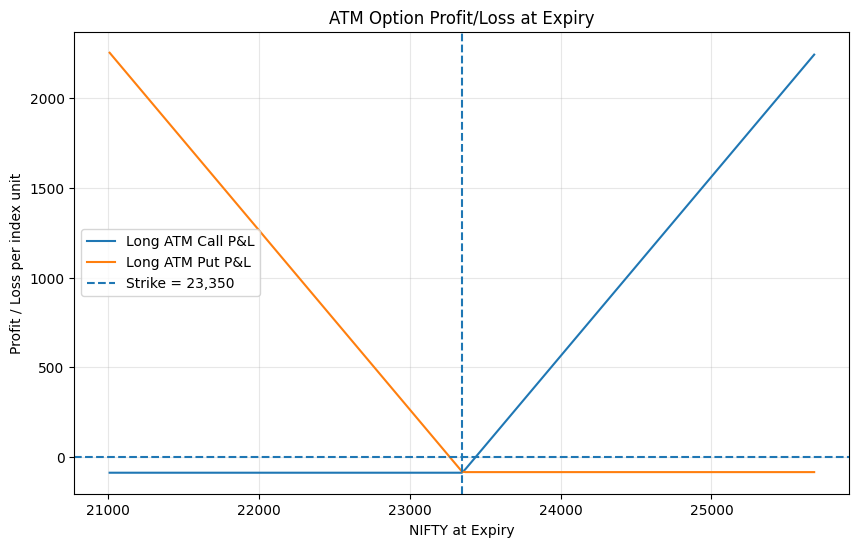

Call breakeven: 23,438.05
Put breakeven : 23,265.35


In [16]:
# CELL 13 — PAYOFF & PROFIT/LOSS AT EXPIRY

spot_grid = np.linspace(S * 0.90, S * 1.10, 201)

call_payoff = np.maximum(spot_grid - K, 0)
put_payoff = np.maximum(K - spot_grid, 0)

call_pnl = call_payoff - call_market
put_pnl = put_payoff - put_market

call_breakeven = K + call_market
put_breakeven = K - put_market

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(spot_grid, call_pnl, label="Long ATM Call P&L")
ax.plot(spot_grid, put_pnl, label="Long ATM Put P&L")
ax.axhline(0, linestyle="--")
ax.axvline(K, linestyle="--", label=f"Strike = {K:,.0f}")
ax.set_xlabel("NIFTY at Expiry")
ax.set_ylabel("Profit / Loss per index unit")
ax.set_title("ATM Option Profit/Loss at Expiry")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Call breakeven: {call_breakeven:,.2f}")
print(f"Put breakeven : {put_breakeven:,.2f}")


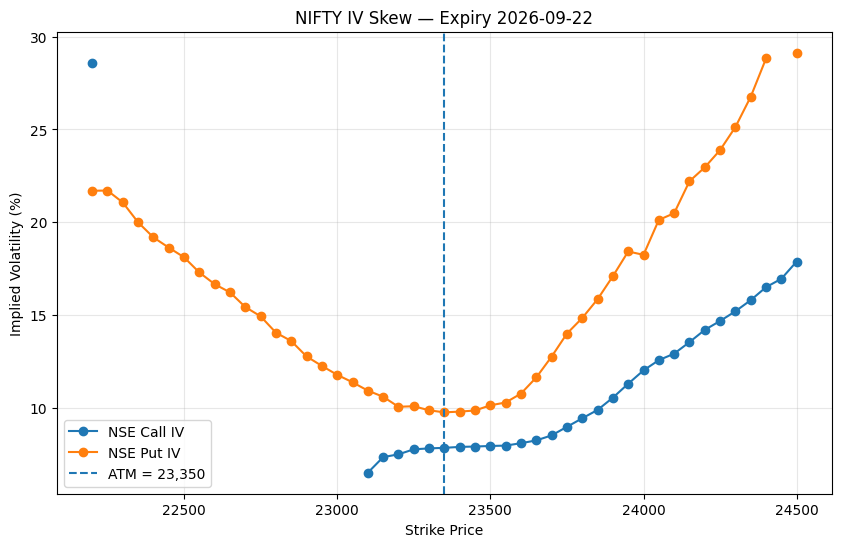

In [17]:
# CELL 14 — REAL NSE IV SKEW / SMILE

lower_bound = S * 0.95
upper_bound = S * 1.05

smile = chain[
    (chain["Strike"] >= lower_bound)
    & (chain["Strike"] <= upper_bound)
].copy()

smile.loc[smile["Call_IV"] <= 0, "Call_IV"] = np.nan
smile.loc[smile["Put_IV"] <= 0, "Put_IV"] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(smile["Strike"], smile["Call_IV"], marker="o", label="NSE Call IV")
ax.plot(smile["Strike"], smile["Put_IV"], marker="o", label="NSE Put IV")
ax.axvline(K, linestyle="--", label=f"ATM = {K:,.0f}")
ax.set_xlabel("Strike Price")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title(f"NIFTY IV Skew — Expiry {expiry_date.date()}")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


ATM CALL P&L SENSITIVITY
Rows = Spot shock | Columns = Relative IV shock


,-20%,-10%,+0%,+10%,+20%
-10%,₹-88.05,₹-88.05,₹-88.05,₹-88.05,₹-88.05
-5%,₹-88.05,₹-88.05,₹-88.05,₹-88.05,₹-88.05
+0%,₹-16.91,₹-8.45,₹0.00,₹8.45,₹16.91
+5%,"₹1,085.95","₹1,085.95","₹1,085.95","₹1,085.95","₹1,085.95"
+10%,"₹2,253.12","₹2,253.12","₹2,253.12","₹2,253.12","₹2,253.12"


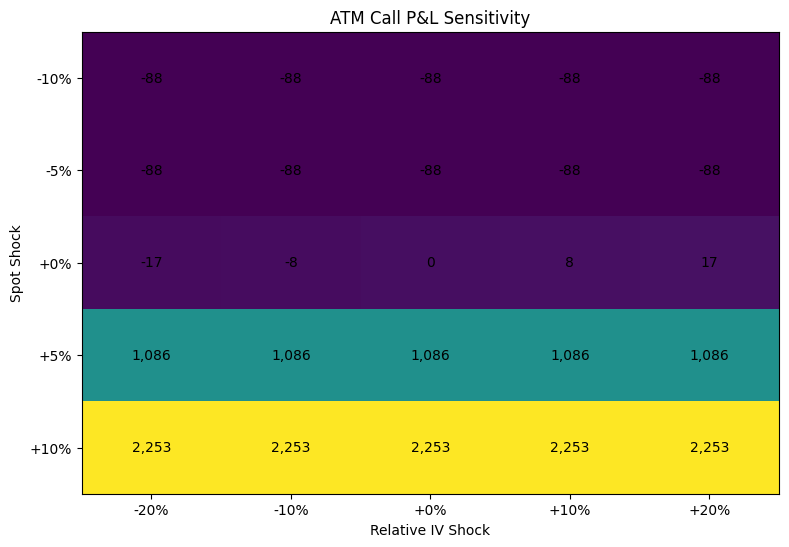

In [18]:
# CELL 15 — SPOT × VOLATILITY SENSITIVITY (ATM CALL)

spot_shocks = np.array([-0.10, -0.05, 0.00, 0.05, 0.10])
vol_shocks = np.array([-0.20, -0.10, 0.00, 0.10, 0.20])

# Use market-implied call IV as the base volatility
base_sigma = our_call_iv
base_option_value = bsm_price(
    S, K, T, r, base_sigma, q, "call"
)

scenario_matrix = pd.DataFrame(
    index=[f"{x:+.0%}" for x in spot_shocks],
    columns=[f"{x:+.0%}" for x in vol_shocks],
    dtype=float
)

for spot_shock in spot_shocks:
    shocked_spot = S * (1 + spot_shock)

    for vol_shock in vol_shocks:
        shocked_vol = max(base_sigma * (1 + vol_shock), 1e-6)

        shocked_price = bsm_price(
            shocked_spot, K, T, r, shocked_vol, q, "call"
        )

        scenario_matrix.loc[
            f"{spot_shock:+.0%}",
            f"{vol_shock:+.0%}"
        ] = shocked_price - base_option_value

print("ATM CALL P&L SENSITIVITY")
print("Rows = Spot shock | Columns = Relative IV shock")
display(scenario_matrix.style.format("₹{:,.2f}"))

fig, ax = plt.subplots(figsize=(9, 6))
heatmap = ax.imshow(scenario_matrix.values, aspect="auto")

ax.set_xticks(range(len(scenario_matrix.columns)))
ax.set_xticklabels(scenario_matrix.columns)
ax.set_yticks(range(len(scenario_matrix.index)))
ax.set_yticklabels(scenario_matrix.index)
ax.set_xlabel("Relative IV Shock")
ax.set_ylabel("Spot Shock")
ax.set_title("ATM Call P&L Sensitivity")

for i in range(len(scenario_matrix.index)):
    for j in range(len(scenario_matrix.columns)):
        ax.text(
            j, i,
            f"{scenario_matrix.iloc[i, j]:,.0f}",
            ha="center", va="center"
        )

plt.show()


In [19]:
# CELL 16 — FINAL DASHBOARD

dashboard = pd.DataFrame({
    "Metric": [
        "Observation Date",
        "NIFTY Spot",
        "ATM Strike",
        "Expiry",
        "Days to Expiry",
        "Call Market LTP",
        "Put Market LTP",
        "NSE Call IV",
        "Our Solved Call IV",
        "NSE Put IV",
        "Our Solved Put IV",
        "30D Realized Vol",
        "90D Realized Vol",
        "BSM Call (30D RV)",
        "Binomial Call (30D RV)",
        "BSM Put (30D RV)",
        "Binomial Put (30D RV)"
    ],
    "Value": [
        str(observation_date.date()),
        f"{S:,.2f}",
        f"{K:,.0f}",
        str(expiry_date.date()),
        str(days_to_expiry),
        f"₹{call_market:.2f}",
        f"₹{put_market:.2f}",
        f"{nse_call_iv:.2%}",
        f"{our_call_iv:.2%}",
        f"{nse_put_iv:.2%}",
        f"{our_put_iv:.2%}",
        f"{rv_30:.2%}",
        f"{rv_90:.2%}",
        f"₹{call_bsm:.2f}",
        f"₹{call_binomial:.2f}",
        f"₹{put_bsm:.2f}",
        f"₹{put_binomial:.2f}"
    ]
})

print("=" * 65)
print("FINAL GROUP PROJECT DASHBOARD")
print("=" * 65)
display(dashboard)


FINAL GROUP PROJECT DASHBOARD


,Metric,Value
0,Observation Date,2026-09-18
1,NIFTY Spot,"23,346.40"
2,ATM Strike,"23,350"
3,Expiry,2026-09-22
4,Days to Expiry,4
5,Call Market LTP,₹88.05
6,Put Market LTP,₹84.65
7,NSE Call IV,7.86%
8,Our Solved Call IV,8.68%
9,NSE Put IV,9.77%


In [20]:
# CELL 17 — AUTOMATED QA

parity_lhs = call_market - put_market
parity_rhs = S*np.exp(-q*T) - K*np.exp(-r*T)
parity_error = parity_lhs - parity_rhs

call_model_diff = abs(call_bsm - call_binomial)
put_model_diff = abs(put_bsm - put_binomial)

qa = pd.DataFrame({
    "Test": [
        "Historical NSE data loaded",
        "Option chain loaded",
        "ATM identified automatically",
        "Call IV solver successful",
        "Put IV solver successful",
        "BSM vs Binomial — Call",
        "BSM vs Binomial — Put",
        "Put-Call Parity Market Error"
    ],
    "Result": [
        len(nifty_history) > 200,
        len(chain) > 0,
        K == chain.loc[chain["Distance_from_Spot"].idxmin(), "Strike"],
        np.isfinite(our_call_iv),
        np.isfinite(our_put_iv),
        call_model_diff < 1,
        put_model_diff < 1,
        abs(parity_error) < 10
    ]
})

qa["Status"] = np.where(qa["Result"], "PASS", "CHECK")

print("=" * 65)
print("FINAL MODEL QA")
print("=" * 65)
print(f"BSM-Binomial Call Gap : ₹{call_model_diff:.4f}")
print(f"BSM-Binomial Put Gap  : ₹{put_model_diff:.4f}")
print(f"Market Parity Error   : ₹{parity_error:.4f}")
print(f"Tests Passed          : {(qa['Status']=='PASS').sum()}/{len(qa)}")

display(qa)

if (qa["Status"] == "PASS").all():
    print("\nPROJECT ENGINE: ALL QA TESTS PASSED")
else:
    print("\nReview CHECK items before submission.")


FINAL MODEL QA
BSM-Binomial Call Gap : ₹0.0158
BSM-Binomial Put Gap  : ₹0.0158
Market Parity Error   : ₹-3.4374
Tests Passed          : 8/8


,Test,Result,Status
0,Historical NSE data loaded,True,PASS
1,Option chain loaded,True,PASS
2,ATM identified automatically,True,PASS
3,Call IV solver successful,True,PASS
4,Put IV solver successful,True,PASS
5,BSM vs Binomial — Call,True,PASS
6,BSM vs Binomial — Put,True,PASS
7,Put-Call Parity Market Error,True,PASS



PROJECT ENGINE: ALL QA TESTS PASSED


## Interpretation Notes

- **BSM vs Binomial:** close model values validate internal implementation consistency when both use the same volatility assumption.
- **Market IV vs solved IV:** differences can arise from rate/dividend assumptions, time conventions, market-price choice and exchange methodology; do not force equality.
- **Realized vs implied volatility:** 30D/90D realized volatility is backward-looking, while option IV is the volatility implied by the current option price over its remaining life.
- **Greeks:** Delta measures directional exposure; Gamma measures Delta curvature; Vega measures volatility sensitivity; Theta captures time decay; Rho captures rate sensitivity.
- **IV skew/smile:** variation in IV across strikes shows that the market does not price all strikes with one constant volatility.
- **Sensitivity:** scenario outputs are model-based changes, not forecasts of future market outcomes.


## Phase 2 — Portfolio Risk & NIFTY Futures Hedging

This extension applies market-risk concepts to a hypothetical ₹10 crore NSE equity portfolio. Historical prices are used to estimate stock betas, portfolio beta, beta-adjusted market exposure, a simple NIFTY futures hedge, and hedged versus unhedged performance under a -5% NIFTY stress scenario.


In [21]:
# CELL 18 — PHASE 2 SETUP

!pip install -q yfinance

import yfinance as yf

print("Phase 2 setup complete")


Phase 2 setup complete


In [22]:
# CELL 19 — CREATE A ₹10 CRORE PORTFOLIO

portfolio_value = 100000000

portfolio = pd.DataFrame({
    "Stock": ["Reliance Industries", "HDFC Bank", "ICICI Bank", "Infosys", "Larsen & Toubro"],
    "Ticker": ["RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", "LT.NS"],
    "Weight": [0.25, 0.20, 0.20, 0.20, 0.15]
})

portfolio["Investment_Value"] = portfolio["Weight"] * portfolio_value

display(portfolio)
print("Total portfolio value: ₹", round(portfolio["Investment_Value"].sum()))
print("Total weight:", portfolio["Weight"].sum())


,Stock,Ticker,Weight,Investment_Value
0,Reliance Industries,RELIANCE.NS,0.2500,"25,000,000.0000"
1,HDFC Bank,HDFCBANK.NS,0.2000,"20,000,000.0000"
2,ICICI Bank,ICICIBANK.NS,0.2000,"20,000,000.0000"
3,Infosys,INFY.NS,0.2000,"20,000,000.0000"
4,Larsen & Toubro,LT.NS,0.1500,"15,000,000.0000"


Total portfolio value: ₹ 100000000
Total weight: 1.0


In [23]:
# CELL 20 — DOWNLOAD PRICES AND CALCULATE BETA

tickers = ["RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", "LT.NS", "^NSEI"]

# Download one year of daily prices
data = yf.download(tickers, period="1y", auto_adjust=True, progress=False)
prices = data["Close"].dropna()
prices = prices.rename(columns={"^NSEI": "NIFTY"})

# Convert prices into daily returns
returns = prices.pct_change().dropna()

stock_tickers = ["RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", "LT.NS"]
betas = {}

# Beta = covariance of stock and market / variance of market
for ticker in stock_tickers:
    covariance = returns[ticker].cov(returns["NIFTY"])
    market_variance = returns["NIFTY"].var()
    betas[ticker] = covariance / market_variance

portfolio["Beta"] = portfolio["Ticker"].map(betas)
portfolio["Weighted_Beta"] = portfolio["Weight"] * portfolio["Beta"]
portfolio_beta = portfolio["Weighted_Beta"].sum()

display(portfolio[["Stock", "Weight", "Beta", "Weighted_Beta"]])
print("Portfolio Beta:", round(portfolio_beta, 3))


,Stock,Weight,Beta,Weighted_Beta
0,Reliance Industries,0.2500,0.9073,0.2268
1,HDFC Bank,0.2000,1.2587,0.2517
2,ICICI Bank,0.2000,0.9461,0.1892
3,Infosys,0.2000,0.7479,0.1496
4,Larsen & Toubro,0.1500,1.4275,0.2141


Portfolio Beta: 1.032


In [24]:
# CELL 21 — CALCULATE NIFTY FUTURES HEDGE

# Market exposure after adjusting for portfolio beta
beta_adjusted_exposure = portfolio_value * portfolio_beta

# Latest NIFTY level from our downloaded data
nifty_level = prices["NIFTY"].iloc[-1]

# NIFTY futures lot size used for this project
nifty_lot_size = 65

contract_value = nifty_level * nifty_lot_size
contracts_required = beta_adjusted_exposure / contract_value
hedge_contracts = round(contracts_required)

print("Portfolio Value: ₹", f"{portfolio_value:,.0f}")
print("Portfolio Beta:", round(portfolio_beta, 3))
print("Beta Adjusted Exposure: ₹", f"{beta_adjusted_exposure:,.0f}")
print("NIFTY Level:", round(nifty_level, 2))
print("Value of one futures contract: ₹", f"{contract_value:,.0f}")
print("Contracts required:", round(contracts_required, 2))
print("Contracts used:", hedge_contracts)
print("Hedge position: SHORT NIFTY futures")


Portfolio Value: ₹ 100,000,000
Portfolio Beta: 1.032
Beta Adjusted Exposure: ₹ 103,152,034
NIFTY Level: 23446.8
Value of one futures contract: ₹ 1,524,042
Contracts required: 67.68
Contracts used: 68
Hedge position: SHORT NIFTY futures


In [25]:
# CELL 22 — SIMPLE STRESS TEST

# Assume NIFTY falls by 5%
market_shock = -0.05

# Approximate portfolio return using beta
estimated_portfolio_return = portfolio_beta * market_shock
unhedged_pnl = portfolio_value * estimated_portfolio_return

# We are short futures, so a market fall gives a profit on the hedge
futures_pnl = -market_shock * nifty_level * nifty_lot_size * hedge_contracts

hedged_pnl = unhedged_pnl + futures_pnl
hedge_effectiveness = (1 - abs(hedged_pnl) / abs(unhedged_pnl)) * 100

print("Estimated Portfolio Return:", f"{estimated_portfolio_return:.2%}")
print("Unhedged P&L: ₹", f"{unhedged_pnl:,.0f}")
print("Futures Hedge P&L: ₹", f"{futures_pnl:,.0f}")
print("Hedged P&L: ₹", f"{hedged_pnl:,.0f}")
print("Hedge Effectiveness:", f"{hedge_effectiveness:.2f}%")


Estimated Portfolio Return: -5.16%
Unhedged P&L: ₹ -5,157,602
Futures Hedge P&L: ₹ 5,181,743
Hedged P&L: ₹ 24,141
Hedge Effectiveness: 99.53%


In [26]:
# CELL 23 — PHASE 2 SUMMARY

phase2_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Value",
        "Portfolio Beta",
        "Beta-Adjusted Exposure",
        "NIFTY Level",
        "NIFTY Futures Contracts (Short)",
        "Stress Scenario",
        "Unhedged P&L",
        "Futures Hedge P&L",
        "Hedged P&L",
        "Hedge Effectiveness"
    ],
    "Result": [
        f"₹{portfolio_value:,.0f}",
        f"{portfolio_beta:.3f}",
        f"₹{beta_adjusted_exposure:,.0f}",
        f"{nifty_level:,.2f}",
        str(hedge_contracts),
        "NIFTY -5%",
        f"₹{unhedged_pnl:,.0f}",
        f"₹{futures_pnl:,.0f}",
        f"₹{hedged_pnl:,.0f}",
        f"{hedge_effectiveness:.2f}%"
    ]
})

display(phase2_summary)


,Metric,Result
0,Portfolio Value,"₹100,000,000"
1,Portfolio Beta,1.032
2,Beta-Adjusted Exposure,"₹103,152,034"
3,NIFTY Level,"23,446.80"
4,NIFTY Futures Contracts (Short),68
5,Stress Scenario,NIFTY -5%
6,Unhedged P&L,"₹-5,157,602"
7,Futures Hedge P&L,"₹5,181,743"
8,Hedged P&L,"₹24,141"
9,Hedge Effectiveness,99.53%
